In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
from Bio import SeqIO
from Bio.Seq import Seq

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from akita_model.model import SeqNN

In [4]:
# 100 strongest CTCFs
ctcf_df = pd.read_csv("/scratch1/smaruj/full_akita_vs_semifreddo/top100_ctcfs.csv")

In [5]:
from pyfaidx import Fasta

In [6]:
genome = Fasta("/project2/fudenber_735/genomes/mm10/mm10.fa")

In [7]:
def get_ctcf_forward_seq(chrom, start, end, strand):
    seq = genome[chrom][start:end].seq
    if strand == "-":
        # reverse complement
        complement = str.maketrans("ACGTacgt", "TGCAtgca")
        seq = seq[::-1].translate(complement)
    return seq.upper()

In [8]:
# Apply to all 100 CTCFs
ctcf_df["ctcf_seq"] = ctcf_df.apply(
    lambda row: get_ctcf_forward_seq(row["chrom"], row["start"], row["end"], row["strand"]), axis=1
)

In [9]:
ctcf_df = ctcf_df[:1]

In [ ]:
ctcf_df

In [10]:
def one_hot_encode(sequence, return_type='numpy', channels_first=False):
    """
    One-hot encode a DNA sequence for Akita input
    
    Parameters:
    -----------
    sequence : str
        DNA sequence string
    return_type : str
        'numpy' or 'torch' - type of array to return
    channels_first : bool
        If True, return shape (4, length) for PyTorch conv layers
        If False, return shape (length, 4)
    
    Returns:
    --------
    np.array or torch.Tensor : One-hot encoded sequence
                                If channels_first=False: (length, 4)
                                If channels_first=True: (4, length)
                                Order: A, C, G, T
    """
    # Mapping for one-hot encoding
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3,
               'a': 0, 'c': 1, 'g': 2, 't': 3,
               'N': -1, 'n': -1}  # Handle N bases
    
    # Initialize array
    seq_len = len(sequence)
    one_hot = np.zeros((seq_len, 4), dtype=np.float32)
    
    # Fill in one-hot encoding
    for i, base in enumerate(sequence):
        if base in mapping:
            idx = mapping[base]
            if idx >= 0:  # Skip N bases
                one_hot[i, idx] = 1.0
            else:  # For N, use uniform distribution
                one_hot[i, :] = 0.25
    
    # Transpose if channels_first
    if channels_first:
        one_hot = one_hot.T  # Shape: (4, length)
    
    if return_type == 'torch':
        import torch
        return torch.from_numpy(one_hot)
    else:
        return one_hot

In [11]:
def reverse_complement(seq):
    """Get reverse complement of a DNA sequence"""
    return str(Seq(seq).reverse_complement())

In [12]:
def insert_ctcfs_at_positions(background_seq, ctcf_seq, ctcf_orientations, 
                               ctcf_positions):
    """
    Insert CTCFs at specified positions with given orientations
    
    Parameters:
    -----------
    background_seq : str
        Background DNA sequence
    ctcf_seq : str
        CTCF motif sequence
    ctcf_orientations : list
        List of orientations for each CTCF ('forward' or 'reverse')
        e.g., ['forward', 'reverse', 'forward', 'reverse'] for ><><
    ctcf_positions : list
        List of positions (in bp) where to insert each CTCF
    
    Returns:
    --------
    str : Modified sequence with CTCFs inserted
    """
    # Make a mutable copy
    seq_list = list(background_seq)
    
    # Create list of insertions
    insertions = []
    for pos, orientation in zip(ctcf_positions, ctcf_orientations):
        if orientation == 'reverse':
            seq_to_insert = reverse_complement(ctcf_seq)
        else:
            seq_to_insert = ctcf_seq
        insertions.append((pos, seq_to_insert))
    
    # Sort by position (descending) to insert from right to left
    insertions.sort(key=lambda x: x[0], reverse=True)
    
    # Insert CTCFs by replacement
    for pos, seq_to_insert in insertions:
        for i, base in enumerate(seq_to_insert):
            if pos + i < len(seq_list):
                seq_list[pos + i] = base
    
    return ''.join(seq_list)


In [13]:
def calculate_ctcf_positions(background_length, outer_ctcf_span_bins, 
                             inner_ctcf_distance_bp, bin_size=2048):
    """
    Calculate positions for 4 CTCFs in ><>< configuration
    
    Layout:
    CTCF1 (>)  <------------ outer_span (CONSTANT) ------------>  CTCF4 (<)
                  CTCF2 (<)  <--inner_distance-->  CTCF3 (>)
    
    Parameters:
    -----------
    background_length : int
        Length of background sequence in bp
    outer_ctcf_span_bins : int
        Total distance from CTCF1 to CTCF4 (in bins) - CONSTANT
        Example: 50 bins = 102,400 bp
    inner_ctcf_distance_bp : int
        Distance between CTCF2 and CTCF3 (in bp) - VARIES
        Minimum: 20 bp (CTCF motif length)
        Example: 20, 10240, 20480, 30720, 40960 bp
    bin_size : int
        Size of one bin in bp
    
    Returns:
    --------
    list : Positions for [CTCF1, CTCF2, CTCF3, CTCF4]
    list : Orientations for each CTCF
    
    Notes:
    ------
    - CTCF1 and CTCF4 positions are CONSTANT (stay at outer_span distance)
    - CTCF2 and CTCF3 move within that fixed span
    - Inner distance is specified in bp for fine control
    - Minimum inner_distance = 20 bp (CTCF motif length, prevents overlap)
    """
    middle_pos = background_length // 2
    
    outer_span_bp = outer_ctcf_span_bins * bin_size
    
    # CTCF1 and CTCF4 are FIXED at outer_span distance, centered in background
    ctcf1_pos = middle_pos - (outer_span_bp // 2)
    ctcf4_pos = middle_pos + (outer_span_bp // 2)
    
    # CTCF2 and CTCF3 are positioned symmetrically around the center
    # They are separated by inner_distance (in bp)
    ctcf2_pos = middle_pos - (inner_ctcf_distance_bp // 2)
    ctcf3_pos = middle_pos + (inner_ctcf_distance_bp // 2)
    
    positions = [ctcf1_pos, ctcf2_pos, ctcf3_pos, ctcf4_pos]
    
    # ><>< orientation
    orientations = ['forward', 'reverse', 'forward', 'reverse']
    
    return positions, orientations

In [14]:
def create_experiment_dataframe(ctcf_df, background_fasta, 
                                outer_ctcf_span=50, 
                                inner_ctcf_distance_steps=[20, 10240, 20480, 30720, 40960, 51200],
                                bin_size=2048):
    """
    Create experiment dataframe with all configurations
    
    Parameters:
    -----------
    ctcf_df : pd.DataFrame
        DataFrame with CTCF information (must have 'ctcf_seq' column)
    background_fasta : str
        Path to background sequences FASTA file
    outer_ctcf_span : int
        Total span from CTCF1 to CTCF4 (in bins) - CONSTANT
        Default: 50 bins = 102,400 bp
    inner_ctcf_distance_steps : list
        List of distances between CTCF2 and CTCF3 to test (in bp) - VARIES
        Default: [20, 10240, 20480, 30720, 40960, 51200] bp
                 (20bp, 5bins, 10bins, 15bins, 20bins, 25bins)
        Minimum: 20 bp (CTCF motif length)
    bin_size : int
        Size of one bin in bp
    
    Returns:
    --------
    pd.DataFrame : Experiment configuration dataframe
    dict : Background sequences
    """
    # Read background sequences
    background_seqs = {record.id: str(record.seq) 
                      for record in SeqIO.parse(background_fasta, "fasta")}
    bg_ids = list(background_seqs.keys())
    
    experiments = []
    
    for idx, row in ctcf_df.iterrows():
        ctcf_seq = row['ctcf_seq']
        
        # Use corresponding background or first one
        if idx < len(bg_ids):
            bg_id = bg_ids[idx]
        else:
            bg_id = bg_ids[0]
        
        bg_seq = background_seqs[bg_id]
        bg_length = len(bg_seq)
        
        # Create experiments for each inner distance
        for inner_dist_bp in inner_ctcf_distance_steps:
            positions, orientations = calculate_ctcf_positions(
                bg_length, outer_ctcf_span, inner_dist_bp, bin_size
            )
            
            exp = {
                'experiment_id': len(experiments),
                'ctcf_id': row.get('seq_id', f'ctcf_{idx}'),
                'background_idx': bg_id,
                'background_length': bg_length,
                'ctcf_seq': ctcf_seq,
                'ctcf_orientations': orientations,
                'outer_ctcf_span_bins': outer_ctcf_span,
                'inner_ctcf_distance_bp': inner_dist_bp,
                'inner_ctcf_distance_bins': inner_dist_bp / bin_size,
                'ctcf1_pos': positions[0],
                'ctcf2_pos': positions[1],
                'ctcf3_pos': positions[2],
                'ctcf4_pos': positions[3],
                'bin_size': bin_size
            }
            
            experiments.append(exp)
    
    return pd.DataFrame(experiments), background_seqs

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [16]:
# Configuration
fasta_file = "/scratch1/smaruj/background_generation/background_sequences_scd30_totvar1300.fasta"
outer_ctcf_span = 50  # bins

# Inner distances in bp (minimum 20bp = CTCF motif length)
# Can also use bins: 5 bins = 10240bp, 10 bins = 20480bp, etc.
inner_ctcf_distance_steps = [20, 10240, 20480, 30720, 40960]  # bp

In [17]:
# Create experiment dataframe
print("Creating experiment configurations...")
exp_df, background_seqs = create_experiment_dataframe(
    ctcf_df, 
    fasta_file,
    outer_ctcf_span=outer_ctcf_span,
    inner_ctcf_distance_steps=inner_ctcf_distance_steps
)

print(f"\nCreated {len(exp_df)} experiment configurations")
print("\nExperiment dataframe columns:")
print(exp_df.columns.tolist())
print("\nFirst few experiments:")
print(exp_df[['experiment_id', 'ctcf_id', 'inner_ctcf_distance_bp', 
                'inner_ctcf_distance_bins', 'outer_ctcf_span_bins',
                'ctcf1_pos', 'ctcf2_pos', 'ctcf3_pos', 'ctcf4_pos']].head())

Creating experiment configurations...

Created 5 experiment configurations

Experiment dataframe columns:
['experiment_id', 'ctcf_id', 'background_idx', 'background_length', 'ctcf_seq', 'ctcf_orientations', 'outer_ctcf_span_bins', 'inner_ctcf_distance_bp', 'inner_ctcf_distance_bins', 'ctcf1_pos', 'ctcf2_pos', 'ctcf3_pos', 'ctcf4_pos', 'bin_size']

First few experiments:
   experiment_id  ctcf_id  inner_ctcf_distance_bp  inner_ctcf_distance_bins  \
0              0     2956                      20                  0.009766   
1              1     2956                   10240                  5.000000   
2              2     2956                   20480                 10.000000   
3              3     2956                   30720                 15.000000   
4              4     2956                   40960                 20.000000   

   outer_ctcf_span_bins  ctcf1_pos  ctcf2_pos  ctcf3_pos  ctcf4_pos  
0                    50     604160     655350     655370     706560  
1           

In [18]:
exp_df

,experiment_id,ctcf_id,background_idx,background_length,ctcf_seq,ctcf_orientations,outer_ctcf_span_bins,inner_ctcf_distance_bp,inner_ctcf_distance_bins,ctcf1_pos,ctcf2_pos,ctcf3_pos,ctcf4_pos,bin_size
0,0,2956,shuffled_0_chrchr8_76333056_77643776_scd29.26_...,1310720,TGGCCACAAGAGGGCACTC,"[forward, reverse, forward, reverse]",50,20,0.009766,604160,655350,655370,706560,2048
1,1,2956,shuffled_0_chrchr8_76333056_77643776_scd29.26_...,1310720,TGGCCACAAGAGGGCACTC,"[forward, reverse, forward, reverse]",50,10240,5.000000,604160,650240,660480,706560,2048
2,2,2956,shuffled_0_chrchr8_76333056_77643776_scd29.26_...,1310720,TGGCCACAAGAGGGCACTC,"[forward, reverse, forward, reverse]",50,20480,10.000000,604160,645120,665600,706560,2048
3,3,2956,shuffled_0_chrchr8_76333056_77643776_scd29.26_...,1310720,TGGCCACAAGAGGGCACTC,"[forward, reverse, forward, reverse]",50,30720,15.000000,604160,640000,670720,706560,2048
4,4,2956,shuffled_0_chrchr8_76333056_77643776_scd29.26_...,1310720,TGGCCACAAGAGGGCACTC,"[forward, reverse, forward, reverse]",50,40960,20.000000,604160,634880,675840,706560,2048


In [19]:
import torch

In [20]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [21]:
import matplotlib.pyplot as plt

In [28]:
256 + 25

281

Processing experiment 1/5: inner_distance=0.02 bins
-0.18835052847862244


<Figure size 800x800 with 0 Axes>

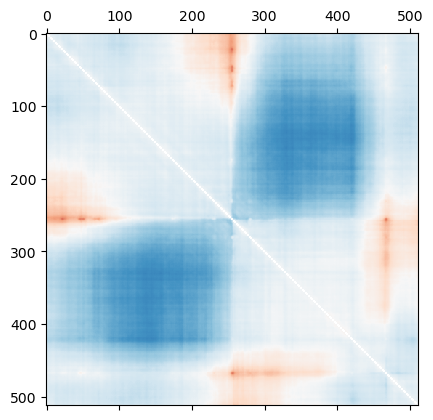

Processing experiment 2/5: inner_distance=10.00 bins
-0.18528331816196442


<Figure size 800x800 with 0 Axes>

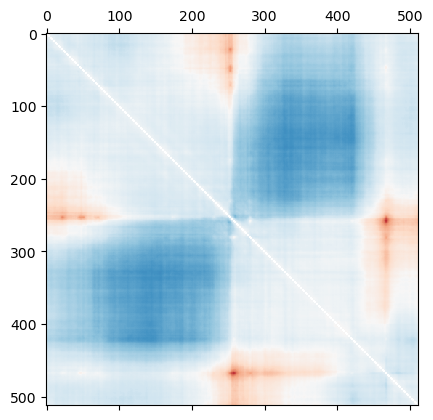

Processing experiment 3/5: inner_distance=20.00 bins
-0.15701714903116226


<Figure size 800x800 with 0 Axes>

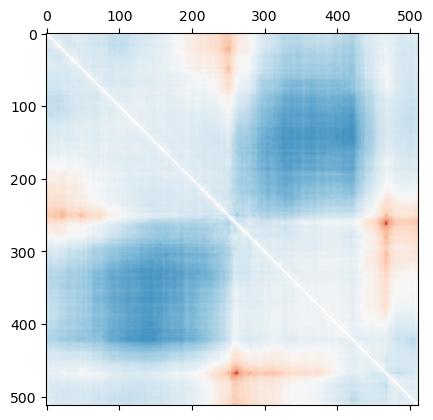

Processing experiment 4/5: inner_distance=30.00 bins
-0.37361617386341095


<Figure size 800x800 with 0 Axes>

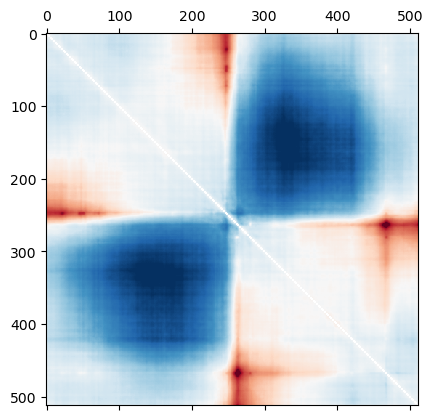

Processing experiment 5/5: inner_distance=40.00 bins
-0.32297005504369736


<Figure size 800x800 with 0 Axes>

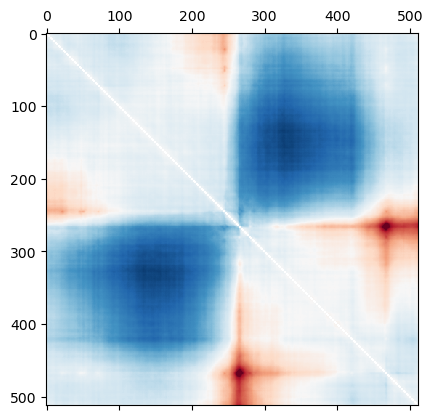

In [30]:
predictions = []
# contact_stats = []

for idx, row in exp_df.iterrows():
    print(f"Processing experiment {idx+1}/{len(exp_df)}: "
            f"inner_distance={row['inner_ctcf_distance_bins']*2:.2f} bins")
    
    # 1. Get the CTCF seq
    ctcf_seq = row['ctcf_seq']
    
    # 2. Get the background seq
    background_seq = background_seqs[row['background_idx']]
    
    # 3. Insert CTCFs into background
    ctcf_positions = [row['ctcf1_pos'], row['ctcf2_pos'], 
                        row['ctcf3_pos'], row['ctcf4_pos']]
    ctcf_orientations = row['ctcf_orientations']
    
    modified_seq = insert_ctcfs_at_positions(
        background_seq, ctcf_seq, ctcf_orientations, ctcf_positions
    )
    
    # 4. One-hot encode the modified background
    # PyTorch: channels_first format (4, length)
    seq_one_hot = one_hot_encode(modified_seq, return_type='torch', channels_first=True)
    # Add batch dimension: (1, 4, length)
    seq_input = seq_one_hot.unsqueeze(0)
    
    # 5. Prediction model(seq)
    with torch.no_grad():
        prediction = model(seq_input)
    # Convert to numpy for statistics calculation
    prediction_np = prediction[0].cpu().numpy()
    
    matrix = from_upper_triu(prediction_np, matrix_len=512, num_diags=2)
    
    print(np.mean(matrix[230:232, 280:282]))
    
    plt.figure(figsize=(8, 8))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    # plt.colorbar()
    plt.show()
    
    # # 6. Keep the predicted map
    # predictions.append(prediction_np)
    
    # 7. Calculate statistics from the prediction
    
    